In [1]:
import xgboost as xgb
import pandas as pd
import numpy as np
from pathlib import Path
import xarray as xr
import dask.dataframe as dd

import seaborn as sns
import matplotlib.pyplot as plt

import os

In [2]:
data_path = Path('/scratch/er8/cd3022/xgb_datasets/')

test_files = []

for f in data_path.glob("all_training_month*"):
    month = f.name.split("_")[-1][:2]  # adjust to your naming

    if month in ['02', '06', '10']:
        test_files.append(str(f))

df = dd.read_parquet(test_files)
df = df.compute()

In [10]:
# Delta data
delta_cols = [col for col in df.columns if col.startswith("delta")]

# All other columns
other_cols = [col for col in df.columns if not col.startswith("delta")]

# Correlation matrices
delta_corr = df[delta_cols].corr(numeric_only=True)
other_corr = df[other_cols].corr(numeric_only=True)

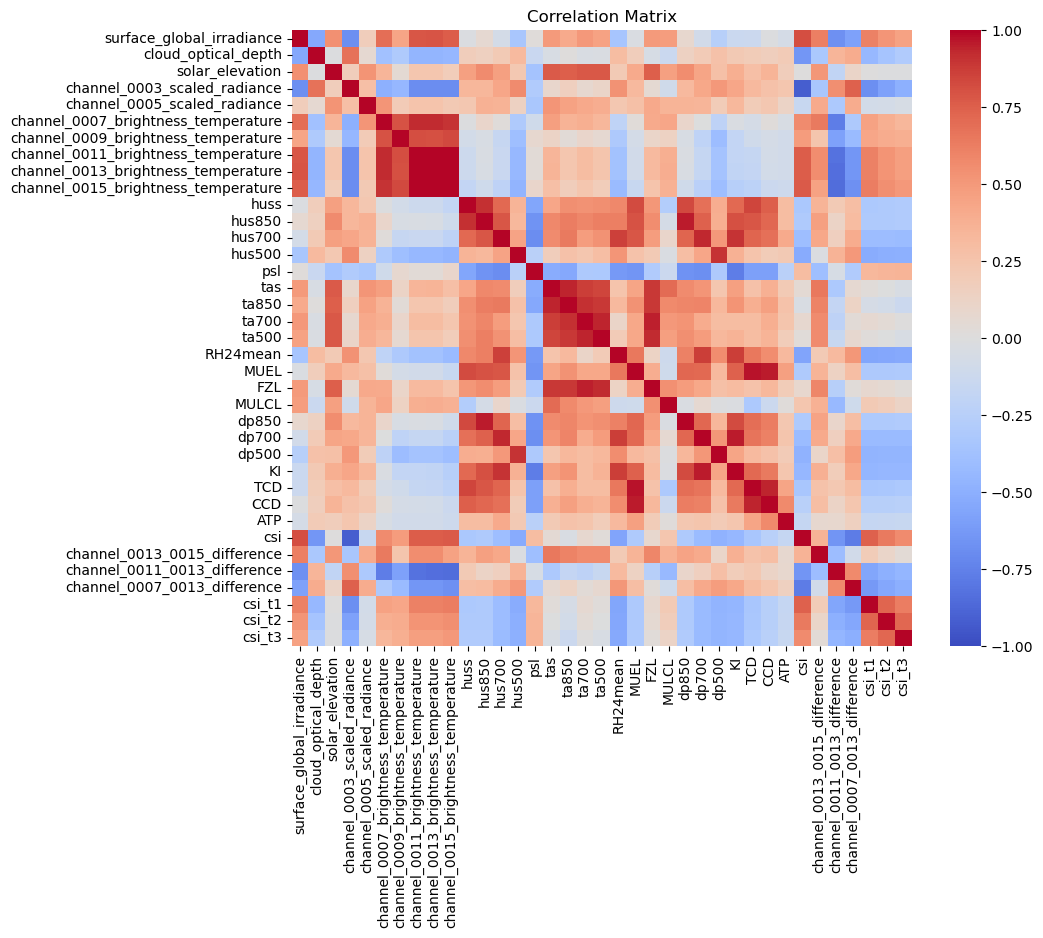

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(other_corr, annot=False, cmap='coolwarm', vmax=1, vmin=-1)

plt.title('Correlation Matrix')
plt.show()

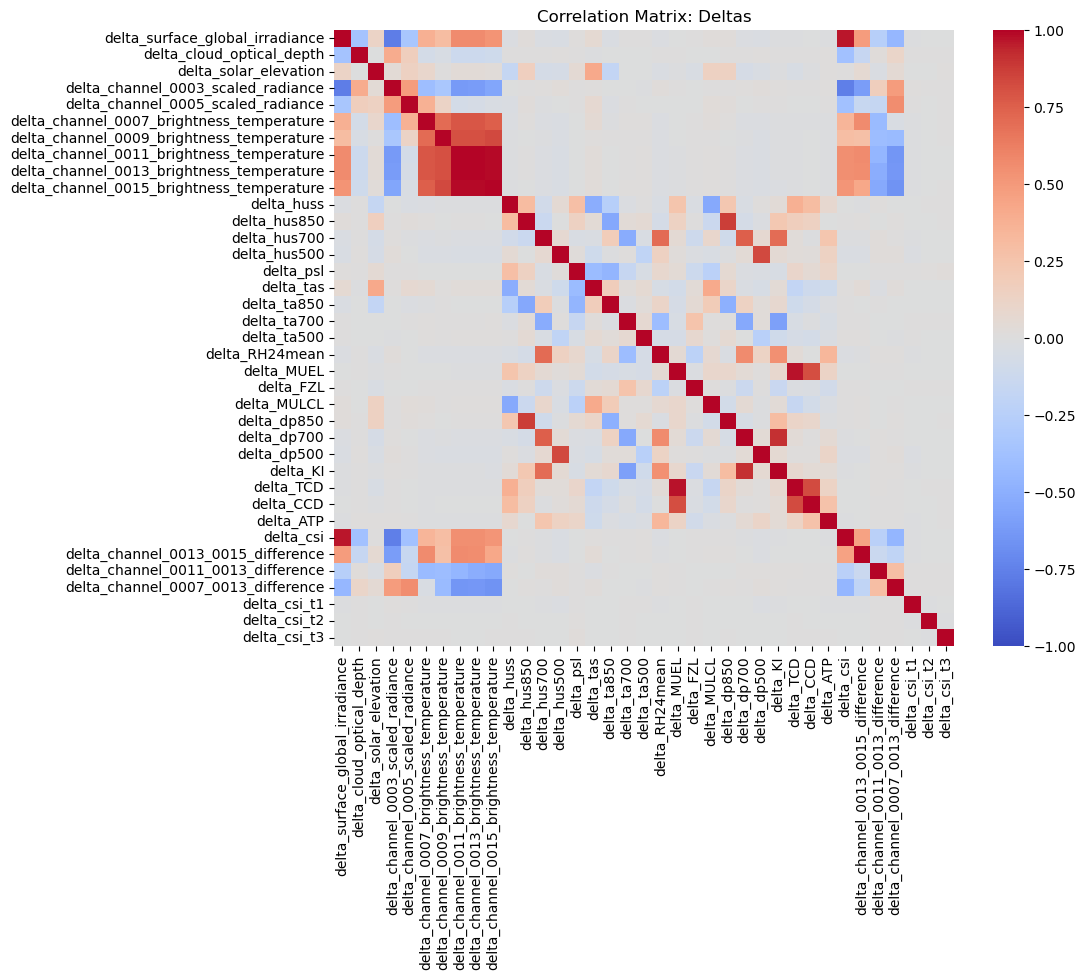

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(delta_corr, annot=False, cmap='coolwarm', vmax=1, vmin=-1)

plt.title('Correlation Matrix: Deltas')
plt.show()